# Texas Hydrographic Infographic

A data-rich infographic poster for the state of Texas, combining the full
NHDPlus HR river network render with key hydrologic statistics, watershed
counts, and the animated year-cycle GIF.

**Data:** USGS NHDPlus HR (21 HUC4 basins), Census state boundary — all federal public domain.

In [ ]:
import sys
from pathlib import Path

REPO = Path(".").resolve().parent
sys.path.insert(0, str(REPO))

import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

%matplotlib inline

# Neon dark theme
BG = "#07080c"
PANEL = "#10121b"
EDGE = "#232838"
TEXT = "#e6ebf5"
TICK = "#8891a8"
CYAN = "#00ffff"
MAGENTA = "#ff4d9a"
LIME = "#00ff9c"
VIOLET = "#9d00ff"
AMBER = "#ff9c3a"
RED = "#ff4d5e"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": PANEL,
    "axes.edgecolor": EDGE,
    "axes.labelcolor": TEXT,
    "text.color": TEXT,
    "xtick.color": TICK,
    "ytick.color": TICK,
    "figure.dpi": 140,
    "savefig.dpi": 140,
    "font.size": 10,
})

OUT = REPO / "output"
PRINT_DIR = OUT / "prints"
PRINT_DIR.mkdir(parents=True, exist_ok=True)

# Texas HUC4 basins from the dataset registry
from src.datasets import REGION_HUC4
TX_HUCS = REGION_HUC4["Texas"]
print(f"Texas: {len(TX_HUCS)} HUC4 basins")
print(f"  {', '.join(TX_HUCS)}")

Texas: 21 HUC4 basins
  1109, 1110, 1112, 1113, 1114, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1304, 1305, 1307, 1308, 1309


## 1. Load Pre-Rendered Assets

The pipeline render (`build.py --region Texas`) produces the full-state SVG+PNG;
the animation (`render_infographic_year.py --state Texas`) produces weekly frames
and a GIF. Load them here.

In [ ]:
# State render — use peak-flow animation frame as hero (full SVG too large to rasterize)
hero_png = OUT / "year_texas" / "week_10.png"  # May = peak flow, most rivers lit
if hero_png.exists():
    hero_img = Image.open(hero_png)
    print(f"Hero image (May peak flow): {hero_img.size}")
else:
    print(f"Waiting for animation: {hero_png}")
    hero_img = None

# Animation GIF
gif_path = OUT / "infographic_year_texas.gif"
if gif_path.exists():
    print(f"Animation GIF: {gif_path.stat().st_size / 1e6:.1f} MB")
else:
    print(f"Waiting for animation: {gif_path}")

# Animation frames
frame_dir = OUT / "year_texas"
if frame_dir.exists():
    frames = sorted(frame_dir.glob("week_*.png"))
    frames = [f for f in frames if "_frame" not in f.name]  # skip temp files
    print(f"Animation frames: {len(frames)} in {frame_dir}")
else:
    frames = []
    print("No animation frames yet")

Hero image (May peak flow): (3038, 2001)
Animation GIF: 4.5 MB
Animation frames: 26 in /Users/neilrunde/code/hydro-art/output/year_texas


## 2. Texas Infographic Poster

Compose a 24x36" poster-format infographic with:
- Hero: full state watershed map
- Stats sidebar: basin count, total river miles, major rivers
- Sample animation frames showing seasonal flow cycle
- Attribution and data sources

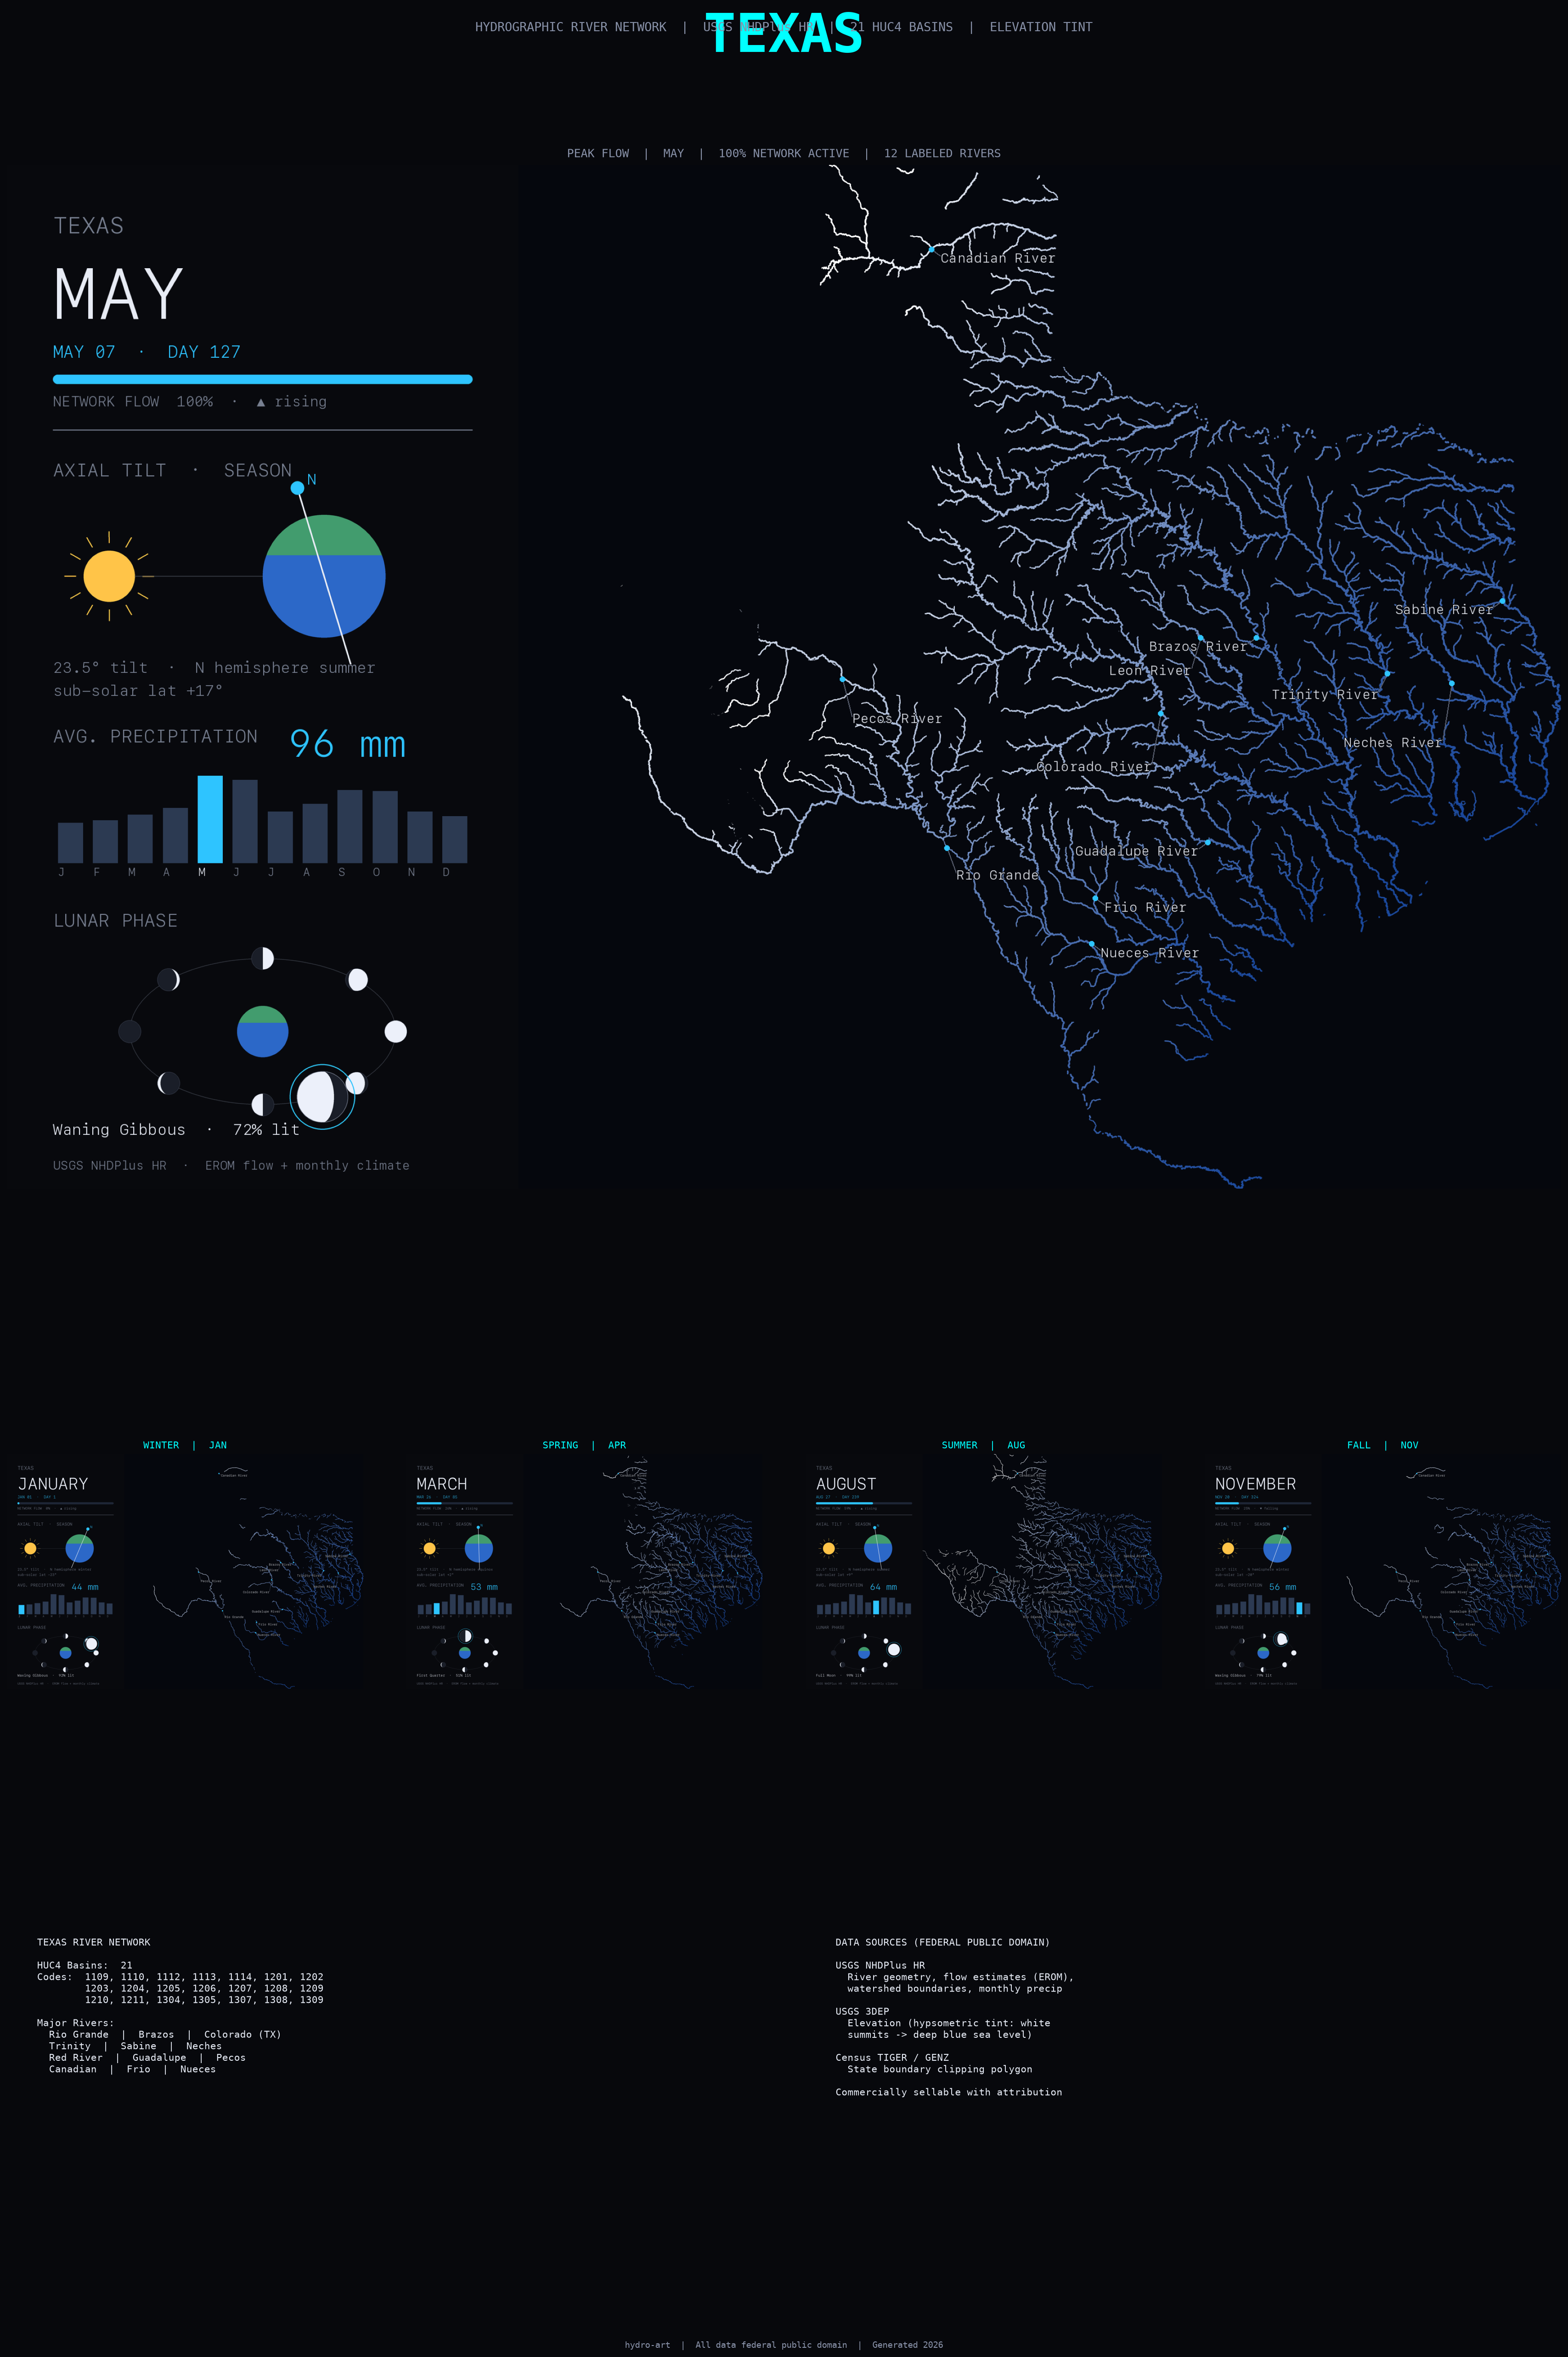


Saved: /Users/neilrunde/code/hydro-art/output/prints/texas_infographic.png (2.1 MB)


In [ ]:
def compose_infographic(hero_img, frames, out_path):
    """Compose a 24x36 poster infographic for Texas."""
    fig = plt.figure(figsize=(24, 36), facecolor=BG, dpi=150)
    gs = GridSpec(4, 4, figure=fig, hspace=0.15, wspace=0.12,
                  left=0.03, right=0.97, top=0.95, bottom=0.02,
                  height_ratios=[0.06, 2.2, 1, 0.8])

    # ── Title banner ──
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.set_facecolor(BG)
    ax_title.set_axis_off()
    ax_title.text(0.5, 0.85, "TEXAS", ha="center", va="top",
                  fontsize=56, fontweight="bold", color=CYAN,
                  fontfamily="monospace", transform=ax_title.transAxes)
    ax_title.text(0.5, 0.1,
                  "HYDROGRAPHIC RIVER NETWORK  |  USGS NHDPlus HR  |  21 HUC4 BASINS  |  ELEVATION TINT",
                  ha="center", va="bottom", fontsize=13, color=TICK,
                  fontfamily="monospace", transform=ax_title.transAxes)

    # ── Hero: peak-flow infographic frame (full width) ──
    ax_map = fig.add_subplot(gs[1, :])
    ax_map.set_facecolor(BG)
    for spine in ax_map.spines.values():
        spine.set_visible(False)
    if hero_img is not None:
        ax_map.imshow(np.array(hero_img))
    ax_map.set_axis_off()
    ax_map.set_title("PEAK FLOW  |  MAY  |  100% NETWORK ACTIVE  |  12 LABELED RIVERS",
                     fontsize=12, color=TICK, pad=8, fontfamily="monospace")

    # ── Seasonal cycle: 4 sample frames ──
    season_picks = {
        "WINTER  |  JAN": 0,
        "SPRING  |  APR": 6,
        "SUMMER  |  AUG": 17,
        "FALL  |  NOV": 23,
    }
    for i, (label, pick) in enumerate(season_picks.items()):
        ax = fig.add_subplot(gs[2, i])
        ax.set_facecolor(BG)
        for spine in ax.spines.values():
            spine.set_color(EDGE)
        if frames and pick < len(frames):
            frame_img = Image.open(frames[pick])
            ax.imshow(np.array(frame_img))
        ax.set_axis_off()
        ax.set_title(label, fontsize=10, color=CYAN, pad=6, fontfamily="monospace")

    # ── Stats panel (bottom left 2 cols) ──
    ax_stats = fig.add_subplot(gs[3, :2])
    ax_stats.set_facecolor(PANEL)
    for spine in ax_stats.spines.values():
        spine.set_color(EDGE)
    ax_stats.set_axis_off()

    stats_lines = [
        "TEXAS RIVER NETWORK",
        "",
        f"HUC4 Basins:  {len(TX_HUCS)}",
        f"Codes:  {', '.join(TX_HUCS[:7])}",
        f"        {', '.join(TX_HUCS[7:14])}",
        f"        {', '.join(TX_HUCS[14:])}",
        "",
        "Major Rivers:",
        "  Rio Grande  |  Brazos  |  Colorado (TX)",
        "  Trinity  |  Sabine  |  Neches",
        "  Red River  |  Guadalupe  |  Pecos",
        "  Canadian  |  Frio  |  Nueces",
    ]
    ax_stats.text(0.04, 0.92, "\n".join(stats_lines),
                  transform=ax_stats.transAxes, va="top",
                  family="monospace", fontsize=10, color=TEXT)

    # ── Data sources panel (bottom right 2 cols) ──
    ax_data = fig.add_subplot(gs[3, 2:])
    ax_data.set_facecolor(PANEL)
    for spine in ax_data.spines.values():
        spine.set_color(EDGE)
    ax_data.set_axis_off()

    data_lines = [
        "DATA SOURCES (FEDERAL PUBLIC DOMAIN)",
        "",
        "USGS NHDPlus HR",
        "  River geometry, flow estimates (EROM),",
        "  watershed boundaries, monthly precip",
        "",
        "USGS 3DEP",
        "  Elevation (hypsometric tint: white",
        "  summits -> deep blue sea level)",
        "",
        "Census TIGER / GENZ",
        "  State boundary clipping polygon",
        "",
        "Commercially sellable with attribution",
    ]
    ax_data.text(0.04, 0.92, "\n".join(data_lines),
                 transform=ax_data.transAxes, va="top",
                 family="monospace", fontsize=10, color=TEXT)

    # ── Footer ──
    fig.text(0.5, 0.006,
             "hydro-art  |  All data federal public domain  |  Generated 2026",
             ha="center", fontsize=9, color=TICK, fontfamily="monospace")

    fig.savefig(out_path, facecolor=BG, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved: {out_path} ({out_path.stat().st_size / 1e6:.1f} MB)")


out = PRINT_DIR / "texas_infographic.png"
compose_infographic(hero_img, frames, out)

## 3. Animation Preview

Show sample frames from the year-cycle animation.

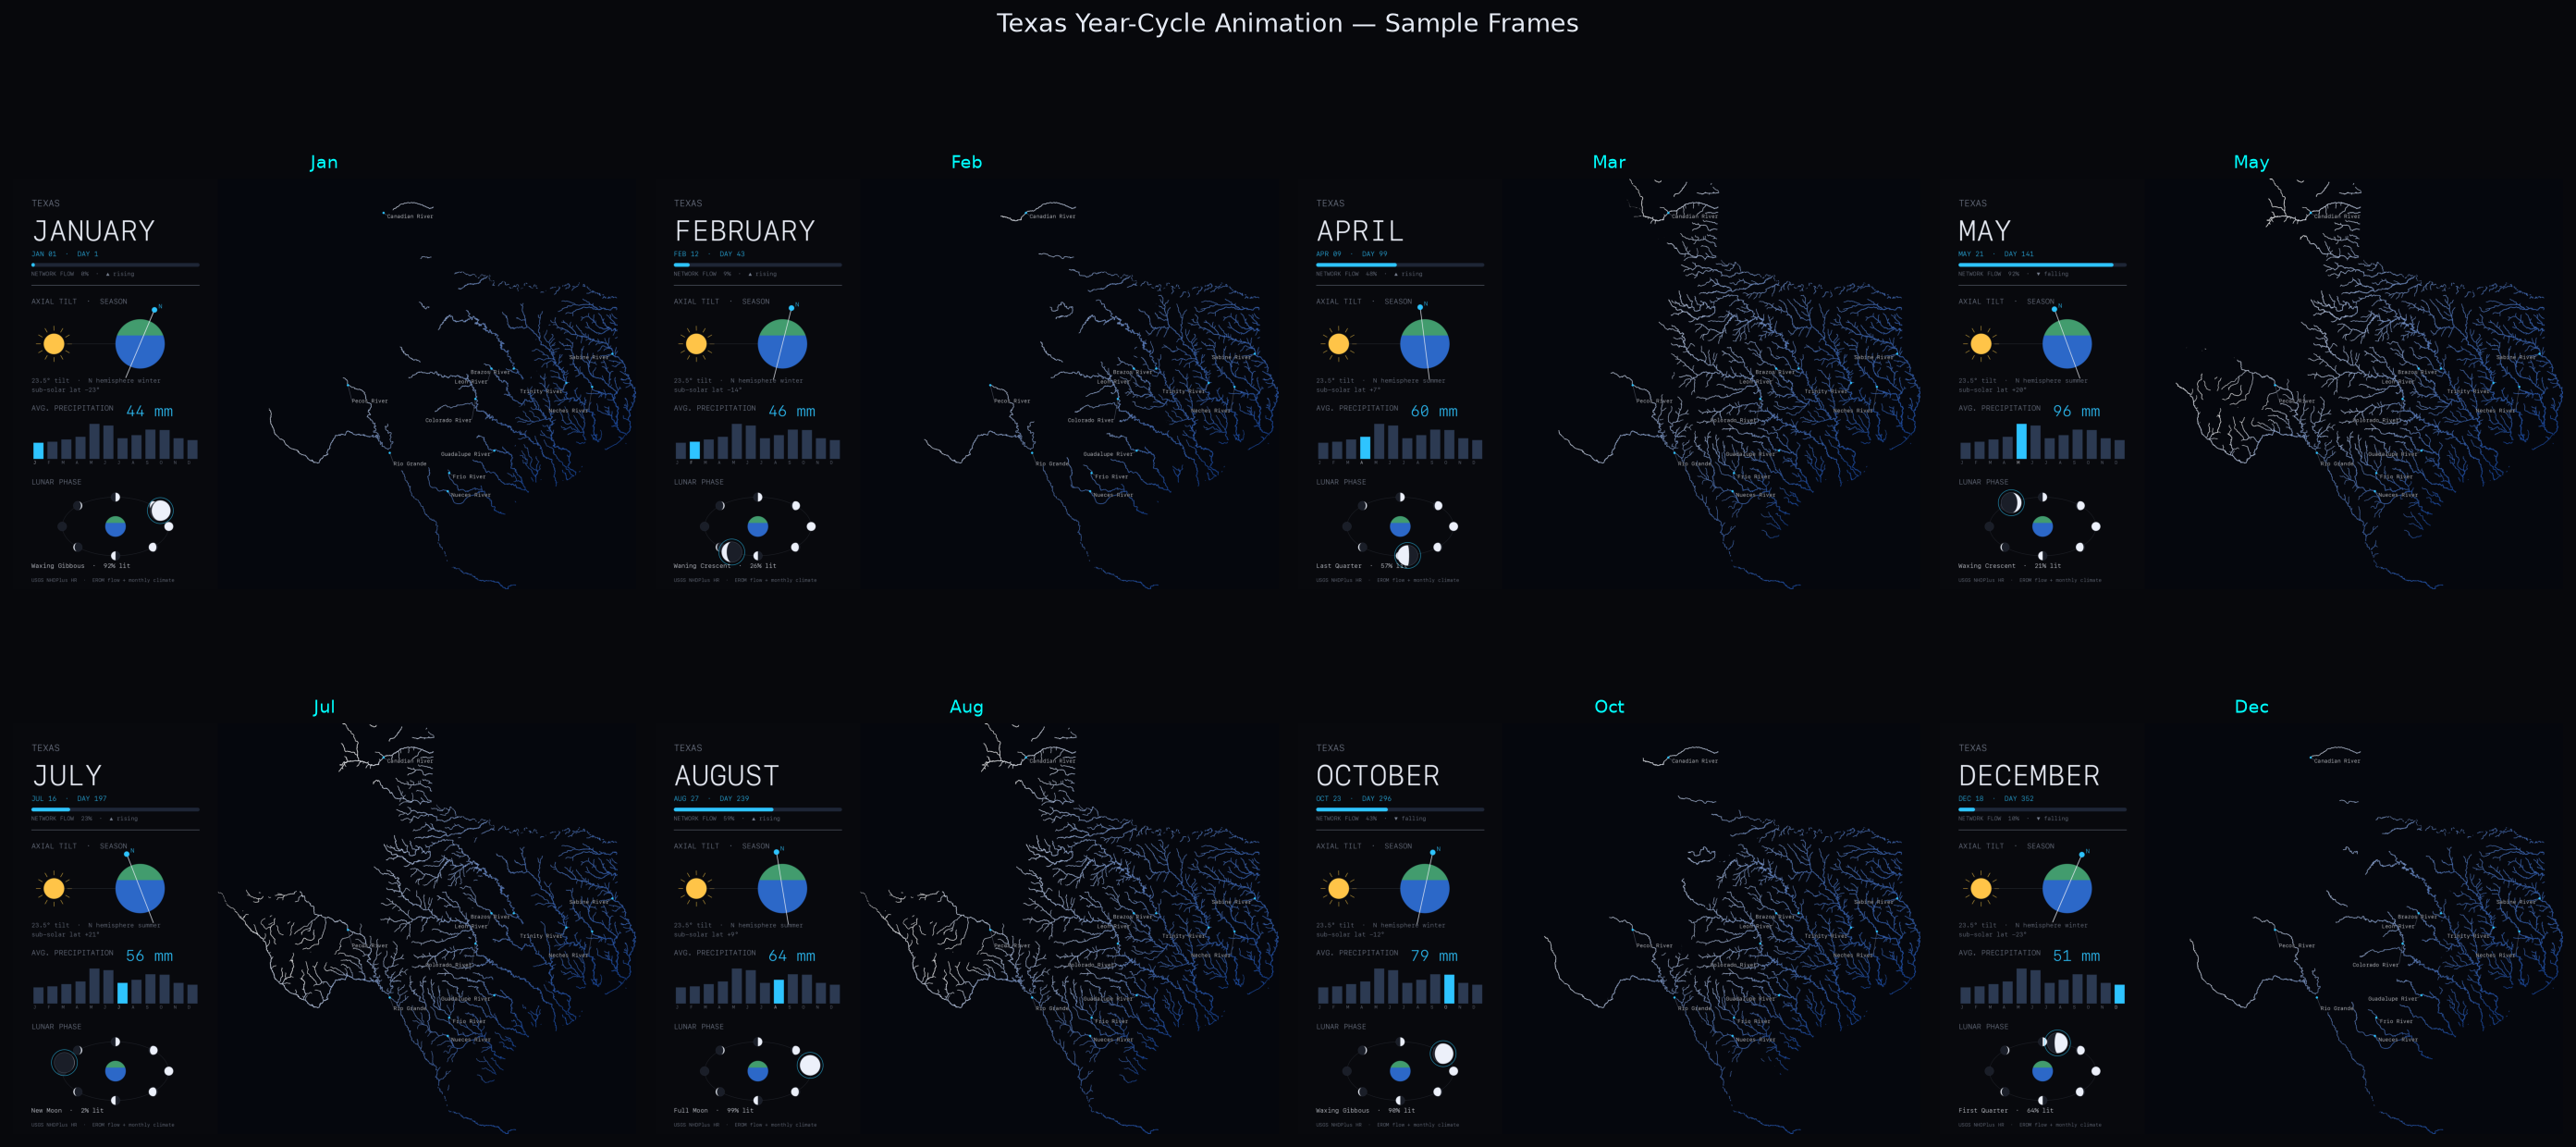


Full animation GIF: /Users/neilrunde/code/hydro-art/output/infographic_year_texas.gif
  Size: 4.5 MB


In [ ]:
if frames and len(frames) >= 8:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    picks = np.linspace(0, len(frames) - 1, 8, dtype=int)
    months = ["Jan", "Feb", "Mar", "May", "Jul", "Aug", "Oct", "Dec"]
    for ax, idx, label in zip(axes.flat, picks, months):
        img = Image.open(frames[idx])
        ax.imshow(np.array(img))
        ax.set_axis_off()
        ax.set_title(label, fontsize=10, color=CYAN)
    plt.suptitle("Texas Year-Cycle Animation — Sample Frames", fontsize=14, color=TEXT)
    plt.tight_layout()
    plt.show()
    
    print(f"\nFull animation GIF: {gif_path}")
    if gif_path.exists():
        print(f"  Size: {gif_path.stat().st_size / 1e6:.1f} MB")
else:
    print("Animation frames not yet available — re-run after render_infographic_year.py completes")